<a href="https://colab.research.google.com/github/ellenwang995/WTI_DEC2027/blob/main/OilPrice2027.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import numpy as np

In [6]:
#Loading the Data

#WTI and Brent
wti = pd.read_excel('WTI_2509.xls', sheet_name='Data 1', header=2)
wti.columns = ['Date', 'WTI']
wti['Date'] = pd.to_datetime(wti['Date'])

brent = pd.read_excel('BRENT_2509.xls', sheet_name='Data 1', header=2)
brent.columns = ['Date', 'Brent']
brent['Date'] = pd.to_datetime(brent['Date'])

#Merge the two sets of crude oil data
crude = pd.merge_asof(brent, wti, on='Date')
crude = crude.sort_values('Date').reset_index(drop=True)

#Setting Date as an Index
crude = crude.set_index('Date')

crude.head(10)

# Crude Prices

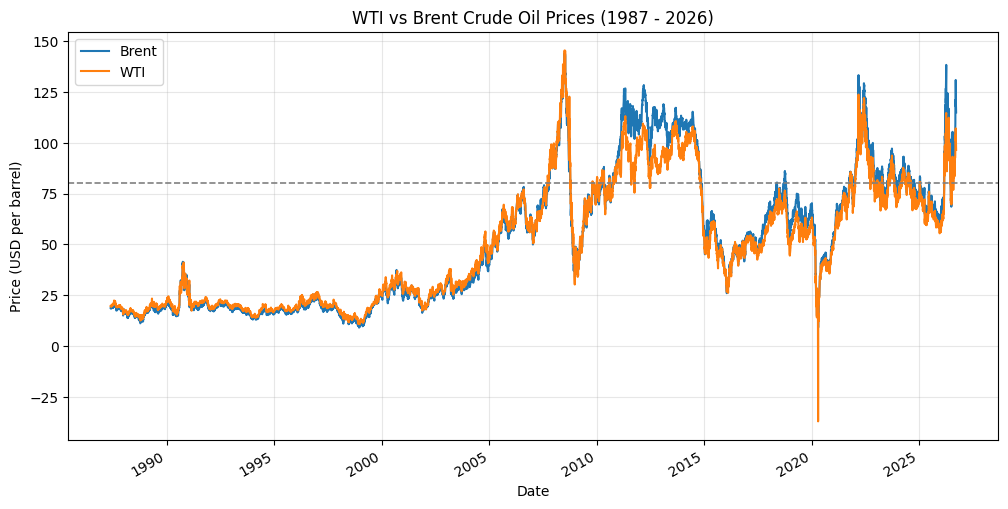

Text(0, 0.5, 'Price (USD per barrel)')

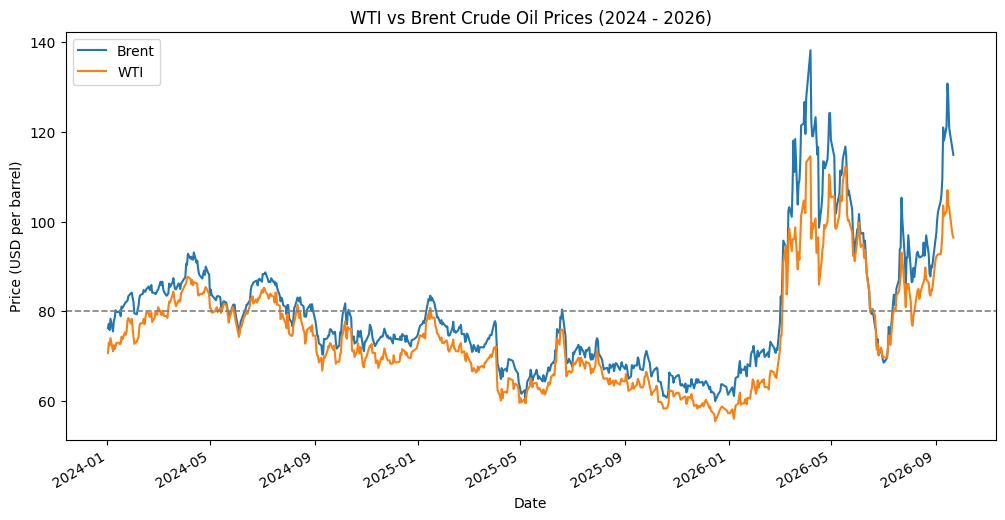

In [17]:
#Plotting WTI and Brent (1987 - 2026)

# 1987 - 2026
crude[['Brent', 'WTI']].plot(figsize=(12, 6))
plt.axhline(80, color='gray', linestyle='--', linewidth=1.2, label='$80')
plt.title('WTI vs Brent Crude Oil Prices (1987 - 2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD per barrel)')
plt.grid(alpha=0.3)
plt.show()

# 2024 - 2026
crude.loc['2024':, ['Brent', 'WTI']].plot(figsize=(12, 6))
plt.axhline(80, color='gray', linestyle='--', linewidth=1.2, label='$80')
plt.title('WTI vs Brent Crude Oil Prices (2024 - 2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD per barrel)')

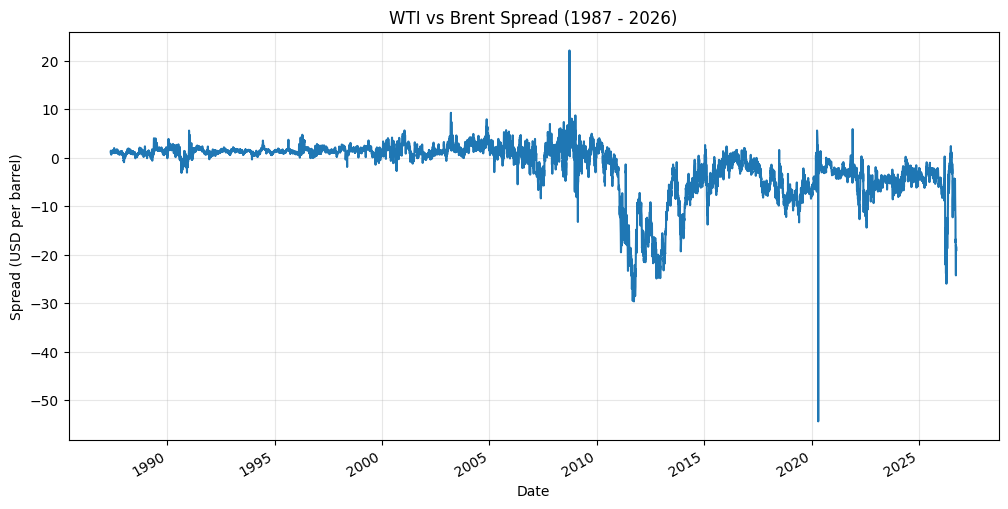

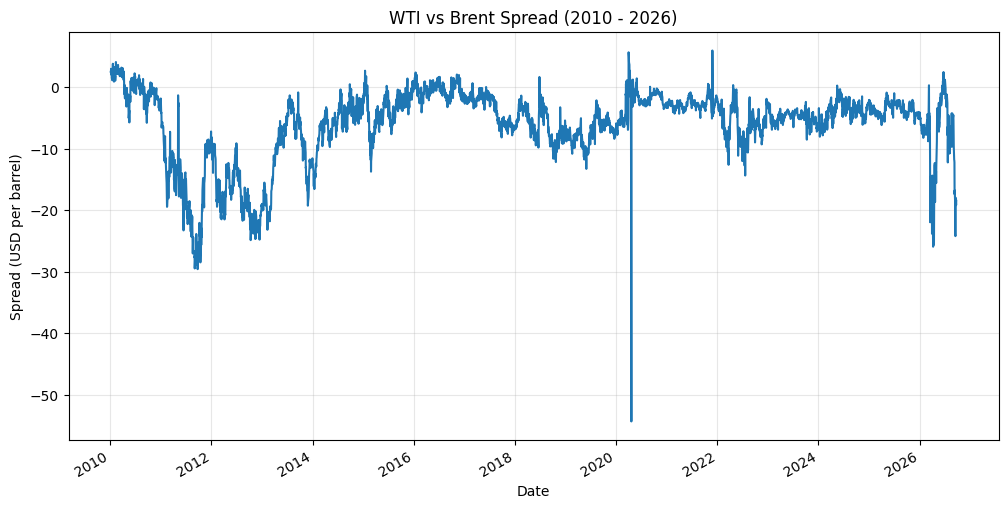

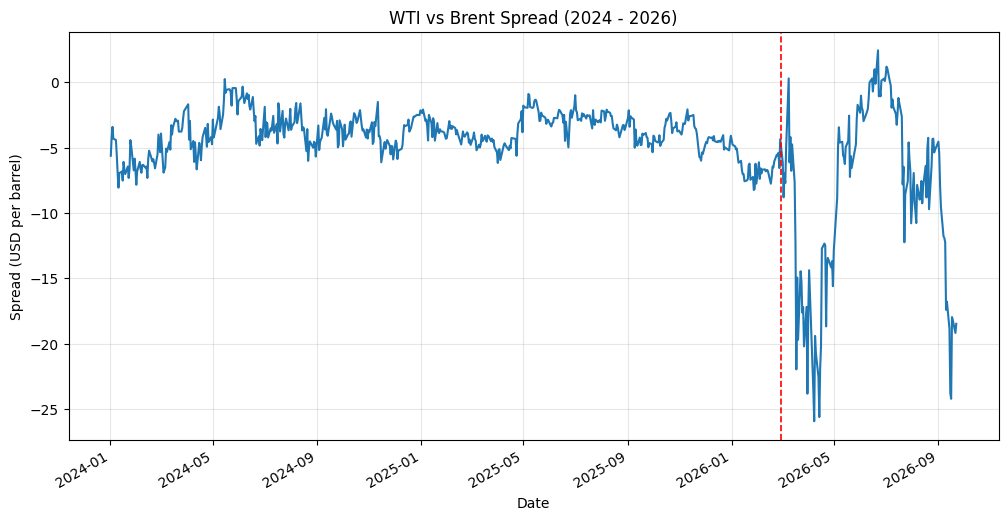

In [13]:
# Plotting the WTI and Brent Spread

crude['Spread'] = crude['WTI'] - crude['Brent']

# 1987 - 2026
crude['Spread'].plot(figsize=(12, 6))
plt.title('WTI vs Brent Spread (1987 - 2026)')
plt.xlabel('Date')
plt.ylabel('Spread (USD per barrel)')
plt.grid(alpha=0.3)
plt.show()

# 2010 - 2026
crude['2010':]['Spread'].plot(figsize=(12, 6))
plt.title('WTI vs Brent Spread (2010 - 2026)')
plt.xlabel('Date')
plt.ylabel('Spread (USD per barrel)')
plt.grid(alpha=0.3)
plt.show()

# 2024 - 2026
crude['2024':]['Spread'].plot(figsize=(12, 6))
plt.axvline(pd.Timestamp('2026-02-28'), color='red', linestyle='--', linewidth=1.2, label='Feb 28, 2026')
plt.title('WTI vs Brent Spread (2024 - 2026)')
plt.xlabel('Date')
plt.ylabel('Spread (USD per barrel)')
plt.grid(alpha=0.3)
plt.show()